## Imports

In [80]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

## Data Loading

In [81]:
TRAIN_PATH = "../../data/transformed/train_t03.parquet"
VAL_PATH   = "../../data/transformed/val_t03.parquet"
TEST_PATH  = "../../data/transformed/test_t03.parquet"

TARGET   = "Results"

train = pd.read_parquet(TRAIN_PATH)
val   = pd.read_parquet(VAL_PATH)
test  = pd.read_parquet(TEST_PATH)

FEATURES = [col for col in train.columns if col != TARGET]

X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"\nTarget distribution (train):\n{y_train.value_counts()}")

Train: (109693, 16) | Val: (27483, 16) | Test: (34294, 16)

Target distribution (train):
Results
0    77306
1    32387
Name: count, dtype: int64


## Feature Scaling

In [82]:
# KNN relies entirely on distances so scaling is mandatory
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete.")
print(f"Feature means (should be ~0): {X_train_scaled.mean(axis=0).round(2)}")
print(f"Feature stds  (should be ~1): {X_train_scaled.std(axis=0).round(2)}")

Scaling complete.
Feature means (should be ~0): [ 0. -0. -0. -0. -0.  0. -0.  0. -0. -0. -0.  0. -0.  0.  0. -0.]
Feature stds  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Undersampling

In [83]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train_scaled, y_train)

print(f"Before: {y_train.value_counts().to_dict()}")
print(f"After:  {pd.Series(y_train_resampled).value_counts().to_dict()}")

Before: {0: 77306, 1: 32387}
After:  {0: 32387, 1: 32387}


## Hyperparamter Definition

In [84]:
params = {
    "n_neighbors": 21,
    "weights":     "distance",
    "metric":      "euclidean",
    "n_jobs":      -1,
}

## Model Training

In [85]:
model = KNeighborsClassifier(**params)
model.fit(X_train_resampled, y_train_resampled)
print("Model ready.")
print(f"Training points stored: {model.n_samples_fit_}")

Model ready.
Training points stored: 64774


## Validation

In [86]:
print("Predicting on validation set... (this may take a few minutes)")

y_val_pred = model.predict(X_val_scaled)
y_val_prob = model.predict_proba(X_val_scaled)[:, 1]

val_cm = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = val_cm.ravel()

val_metrics = {
    "val_accuracy":            accuracy_score(y_val, y_val_pred),
    "val_f1":                  f1_score(y_val, y_val_pred),
    "val_roc_auc":             roc_auc_score(y_val, y_val_prob),
    "val_precision":           precision_score(y_val, y_val_pred),
    "val_recall":              recall_score(y_val, y_val_pred),
    "val_false_negative_rate": fn / (fn + tp),
    "val_failing_catch_rate":  tp / (tp + fn),
}

print("=== VALIDATION METRICS ===")
for k, v in val_metrics.items():
    print(f"  {k:<35} {v:.4f}")

print(f"\nConfusion Matrix (Val):\n{val_cm}")
print(f"\nClassification Report (Val):\n")
print(classification_report(y_val, y_val_pred, target_names=["Pass (0)", "Fail (1)"]))

Predicting on validation set... (this may take a few minutes)
=== VALIDATION METRICS ===
  val_accuracy                        0.7719
  val_f1                              0.6543
  val_roc_auc                         0.8397
  val_precision                       0.6016
  val_recall                          0.7171
  val_false_negative_rate             0.2829
  val_failing_catch_rate              0.7171

Confusion Matrix (Val):
[[15282  3929]
 [ 2340  5932]]

Classification Report (Val):

              precision    recall  f1-score   support

    Pass (0)       0.87      0.80      0.83     19211
    Fail (1)       0.60      0.72      0.65      8272

    accuracy                           0.77     27483
   macro avg       0.73      0.76      0.74     27483
weighted avg       0.79      0.77      0.78     27483



## Testing

In [87]:
print("Predicting on test set... (this may take a few minutes)")

y_test_pred = model.predict(X_test_scaled)
y_test_prob = model.predict_proba(X_test_scaled)[:, 1]

test_cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = test_cm.ravel()

test_metrics = {
    "test_accuracy":            accuracy_score(y_test, y_test_pred),
    "test_f1":                  f1_score(y_test, y_test_pred),
    "test_roc_auc":             roc_auc_score(y_test, y_test_prob),
    "test_precision":           precision_score(y_test, y_test_pred),
    "test_recall":              recall_score(y_test, y_test_pred),
    "test_false_negative_rate": fn / (fn + tp),
    "test_failing_catch_rate":  tp / (tp + fn),
}

print("=== TEST METRICS ===")
for k, v in test_metrics.items():
    print(f"  {k:<35} {v:.4f}")

print(f"\nConfusion Matrix (Test):\n{test_cm}")
print(f"\nClassification Report (Test):\n")
print(classification_report(y_test, y_test_pred, target_names=["Pass (0)", "Fail (1)"]))

Predicting on test set... (this may take a few minutes)
=== TEST METRICS ===
  test_accuracy                       0.8061
  test_f1                             0.7967
  test_roc_auc                        0.8870
  test_precision                      0.8126
  test_recall                         0.7815
  test_false_negative_rate            0.2185
  test_failing_catch_rate             0.7815

Confusion Matrix (Test):
[[14610  3006]
 [ 3644 13034]]

Classification Report (Test):

              precision    recall  f1-score   support

    Pass (0)       0.80      0.83      0.81     17616
    Fail (1)       0.81      0.78      0.80     16678

    accuracy                           0.81     34294
   macro avg       0.81      0.81      0.81     34294
weighted avg       0.81      0.81      0.81     34294



## Confution Matrices

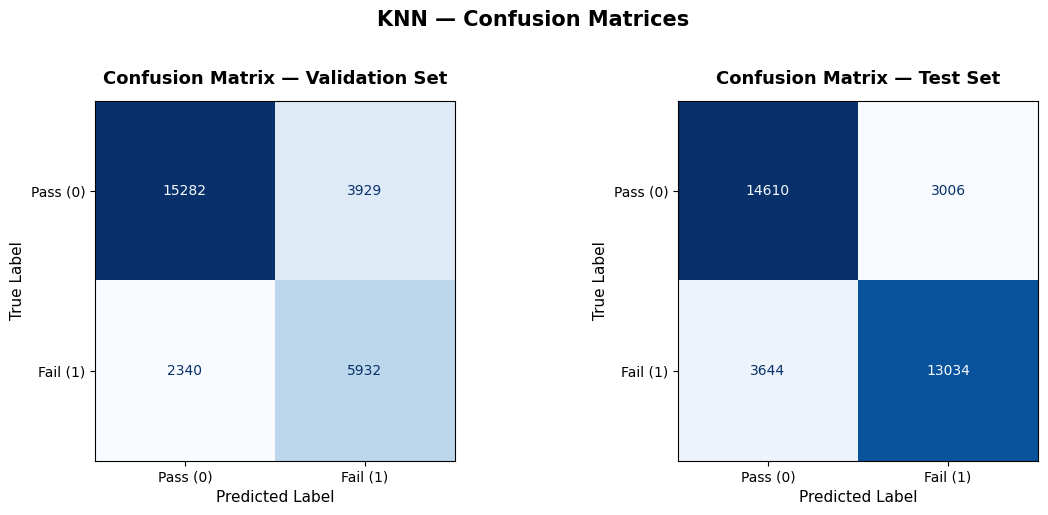

Saved as confusion_matrix_knn.png


In [88]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title in zip(
    axes,
    [val_cm, test_cm],
    ["Validation Set", "Test Set"]
):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Pass (0)", "Fail (1)"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {title}", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)

plt.suptitle("KNN — Confusion Matrices", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrix_knn.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as confusion_matrix_knn.png")

## MLflow Exporting

In [89]:
knn_output = {
    "model":        model,
    "scaler":       scaler,
    "params":       params,
    "val_metrics":  val_metrics,
    "test_metrics": test_metrics,
    "features":     FEATURES,
}

print("KNN output ready for experiment_tracking.py")
print(f"Val F1:  {val_metrics['val_f1']:.4f}")
print(f"Test F1: {test_metrics['test_f1']:.4f}")

KNN output ready for experiment_tracking.py
Val F1:  0.6543
Test F1: 0.7967
